# **New Section # 21**
**Deploying Machine Learning Models**

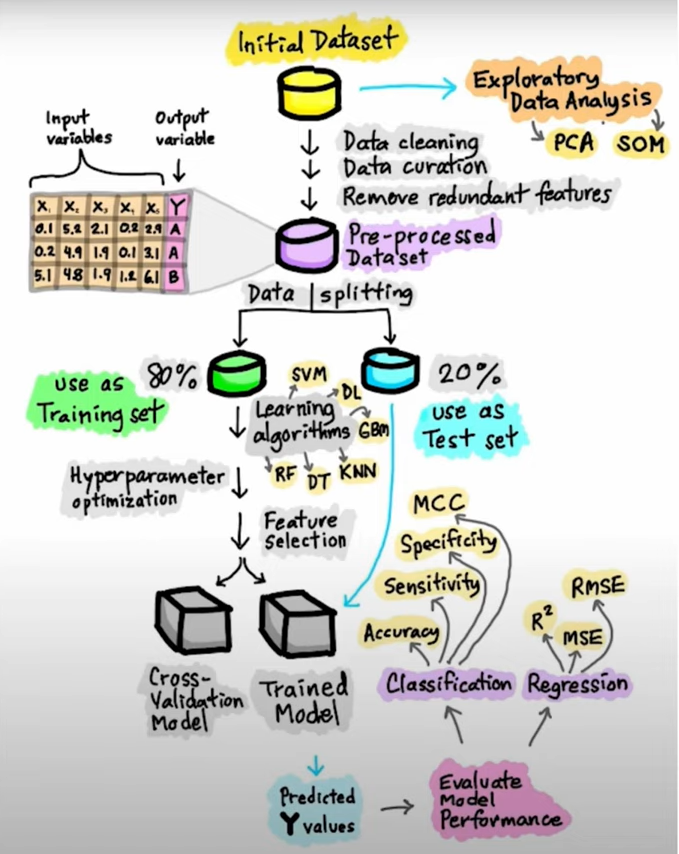


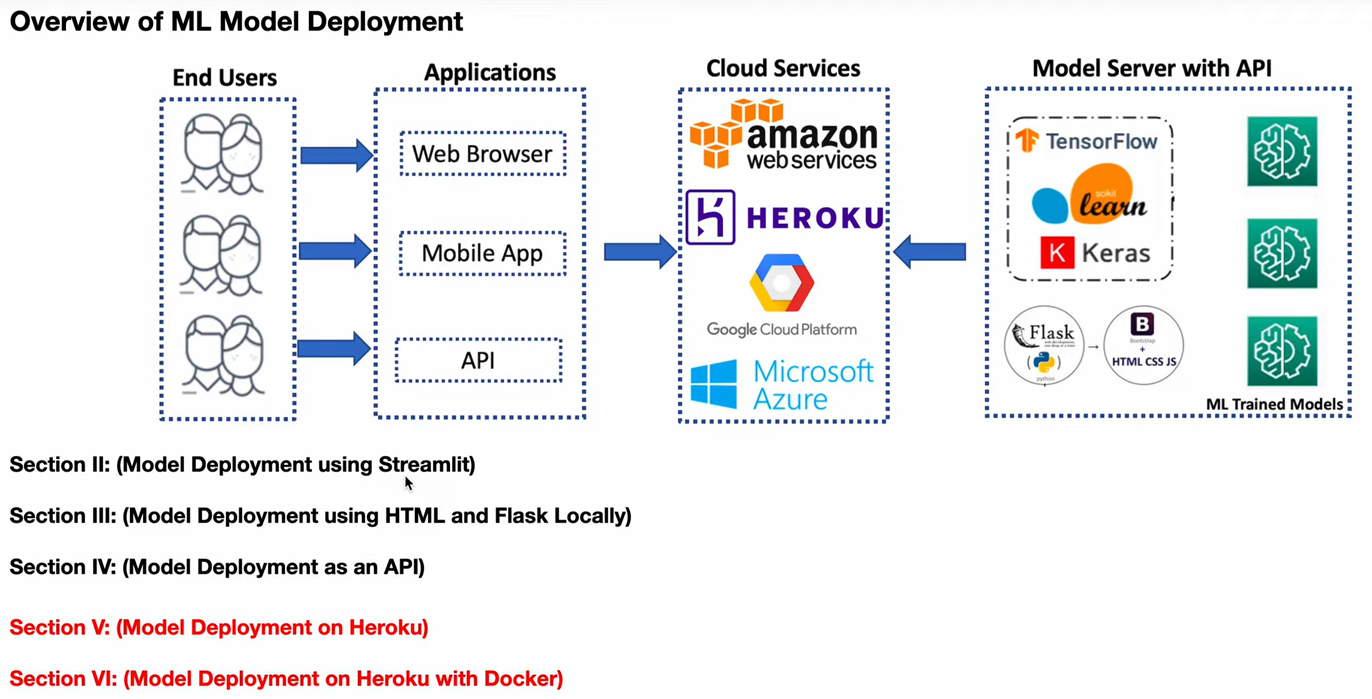


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config
import seaborn as sns

df = pd.read_csv(r'D:\Codes\MachineLearning\Datasets\advertising-withmissingdata.csv')
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,NaN,45.1,10.4
2,NaN,45.9,69.3,9.3
3,151.5,41.3,NaN,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,NaN,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,NaN,25.5


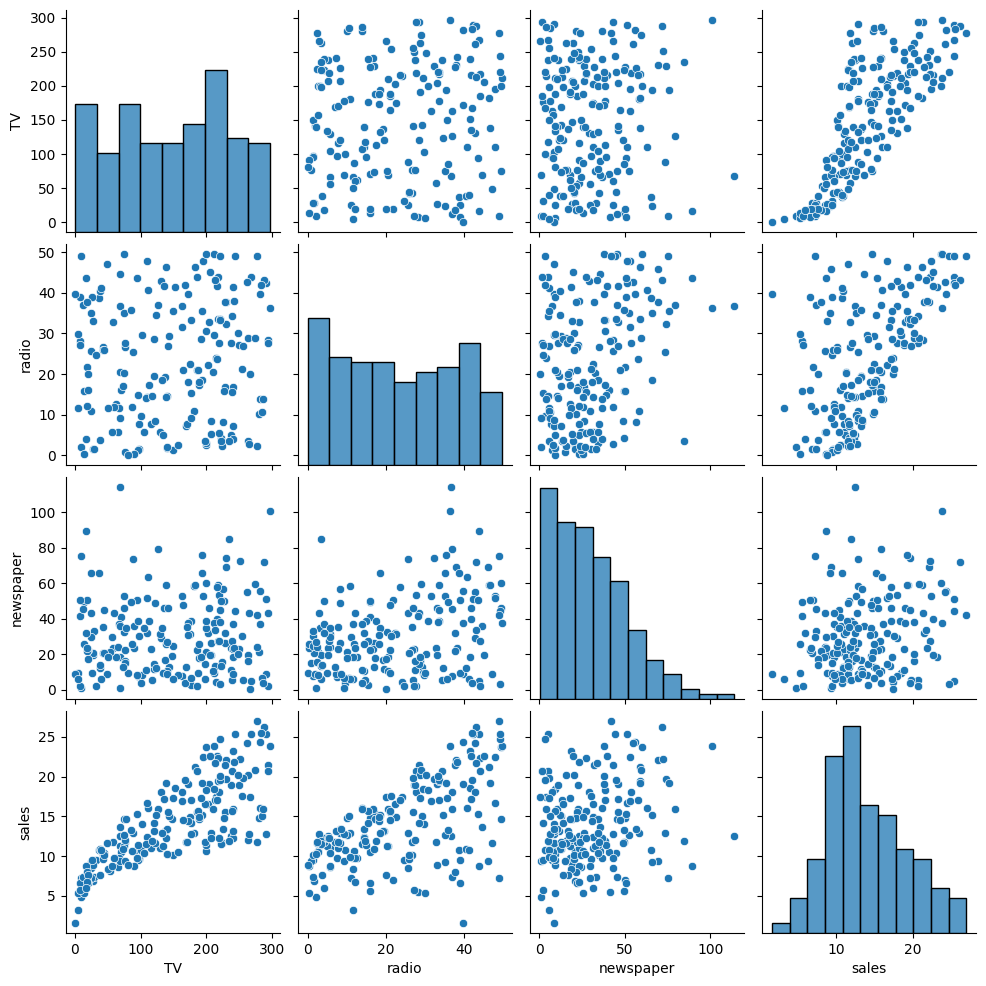

In [2]:
sns.pairplot(df)

In [3]:
df.dtypes

TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

In [4]:
df.isna().sum()

TV            4
radio        10
newspaper     2
sales         0
dtype: int64

<Axes: ylabel='TV'>

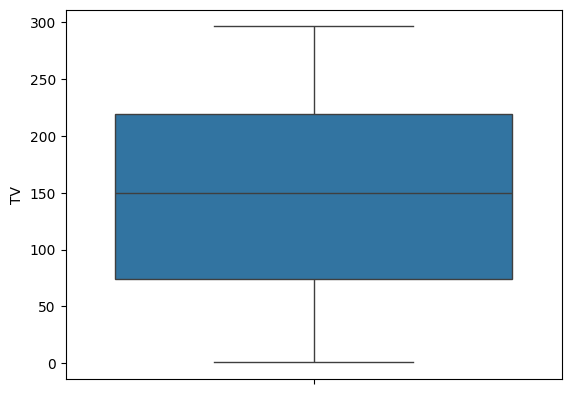

In [5]:
sns.boxplot(df['TV'])

<Axes: ylabel='newspaper'>

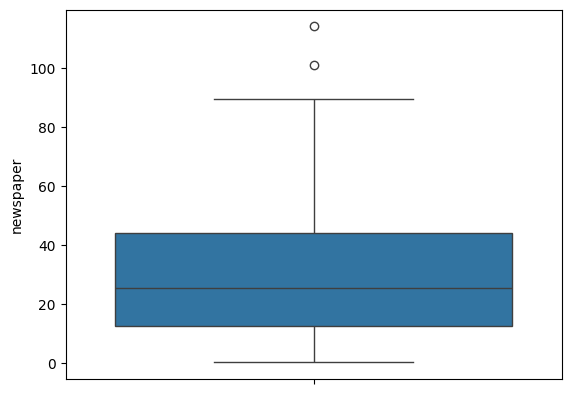

In [6]:
sns.boxplot(df['newspaper'])

<Axes: ylabel='radio'>

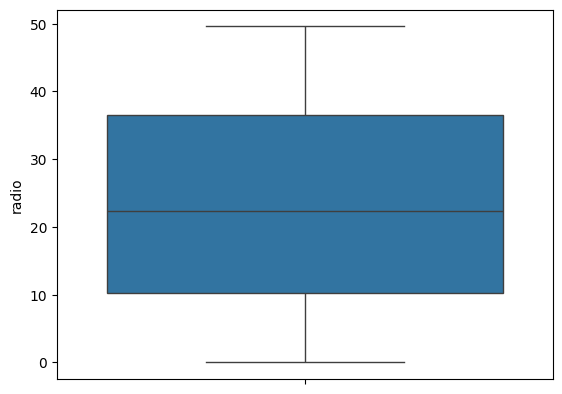

In [7]:
sns.boxplot(df['radio'])

In [8]:
# Q1 = df['newspaper'].quantile(0.25)
# Q3 = df['newspaper'].quantile(0.75)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# df = df[(df['newspaper'] >= lower_bound) & (df['newspaper'] <= upper_bound)]
# df

In [9]:
pipe_line = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

HoldOut Split


In [10]:
X = df.drop('sales', axis=1)
y = df['sales']
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.1, random_state=54)
print(len(X_train))
print(len(X_holdout))

180
20


Validation split


In [11]:
X = df.drop('sales', axis=1)
y = df['sales']
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=54)
print(len(X_train))
print(len(X_test))

144
36


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

pipe_line.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [13]:
y_pred = pipe_line.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = pipe_line.score(X_test, y_test)

print('MAE:', mae)
print('RMSE:', rmse)
print('R²:', r2)

MAE: 1.487790227361201
RMSE: 3.10937506380375
R²: 0.9043782054522596


Cross Validation


In [16]:
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(pipe_line, X_test, y_test, cv=5, scoring='r2').mean()
print('CV R²:', cv_score)

CV R²: 0.7857135971259904


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

params = {
    "ridge__alpha": [1000, 100, 10, 5, 1, 0.8, 0.5, 0.2],
    "ridge__solver": ['lsqr', 'svd']
}

ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean', missing_values=np.nan)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

gs = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

gs.fit(X_train, y_train)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,"{'ridge__alpha': [1000, 100, ...], 'ridge__solver': ['lsqr', 'svd']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [20]:
print("Best CV R²:", gs.best_score_)
print("Best Parameters:", gs.best_params_)

Best CV R²: 0.8252265164860774
Best Parameters: {'ridge__alpha': 1, 'ridge__solver': 'svd'}


In [21]:
pipe_line.fit(X,y)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


Saving Model


In [22]:
import joblib
joblib.dump(pipe_line, 'SalesModel.pkl')

['SalesModel.pkl']

Load And Predict the Model


In [23]:
loaded_model = joblib.load('SalesModel.pkl')


In [24]:
tv = 50
newspaper = 25
radio =5
input = np.array([[tv, newspaper, radio]])
y_pred = loaded_model.predict(input)

d:\Codes\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [25]:
y_pred

array([9.89006076])

**Deploying Machine Learning Models Process:**


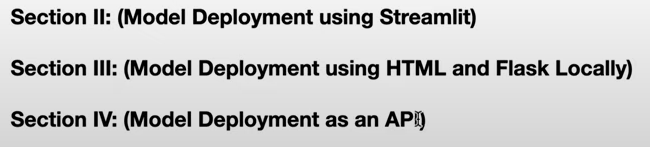


In [26]:
!pip install streamlit

In [27]:
import joblib as jb
import pandas as pd
import streamlit as st

model = jb.load('SalesModel.pkl')
st.title('Advertising Budget Prediction')
tv = st.number_input('TV', step=1)
radio = st.number_input('Radio', step=1)
newspaper = st.number_input('Newspaper', step=1)

new_data = pd.DataFrame({'TV':tv, 'Radio':radio, 'Newspaper':newspaper,}, index=[0])

result=''

if st.button('Predict'):
  result = model.predict(new_data)
  st.subheader("Predicted Sale of items (in thousand units)")
  st.subheader(result)
else:
  st.subheader("Enter ad Budget and click Predict button.")


2025-10-22 18:42:21.340 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-22 18:42:21.564 
  command:

    streamlit run d:\Codes\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-10-22 18:42:21.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-22 18:42:21.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-22 18:42:21.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-22 18:42:21.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-22 18:42:21.567 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-22 18:42:21.568 Thread 'MainThread': missing Scri